In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.multioutput import RegressorChain
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [4]:
from matplotlib.font_manager import FontProperties
from matplotlib.font_manager import findfont

#sns.set_palette([  "#89A8F6","#0F42C6",'#C9CED5',  "#1C2029"])

sns.set_style('darkgrid',{
    "axes.facecolor": "#f0f0f0",
    "axes.linewidth": 1.5,
    'axes.grid': True,
    'axes.labelcolor': '#000',
    "font.size": 18,
    'axes.edgecolor': '#fff',
    'grid.color': '#9d9d9d',
    'text.color': '#000',
    'xtick.color': '#000'
})

In [5]:
def generate_test_data(n_samples=500):
    np.random.seed(42)

    D_values = [2, 5, 10, 15, 20]
    W_values = [10, 30, 100, 300, 1000]
    F_values = [0.3, 0.6, 0.95]
    approaches = ["A", "B", "C"]
    profiles = ["build_system", "file_manager", "web_server", "backup", "refactoring"]
    distributions = ["uniform", "zipf"]
    localities = [0.0, 0.8]
    zipf_s_values = [0.0, 1.0]

    profile_weights = {
        "build_system": [0.4, 0.3, 0.1, 0.1, 0.05, 0.05],
        "file_manager": [0.3, 0.2, 0.2, 0.2, 0.05, 0.05],
        "web_server": [0.8, 0.1, 0.0, 0.1, 0.0, 0.0],
        "backup": [0.1, 0.7, 0.0, 0.0, 0.2, 0.0],
        "refactoring": [0.1, 0.1, 0.1, 0.1, 0.5, 0.1],
    }

    data = []

    for _ in range(n_samples):
        D = np.random.choice(D_values)
        W = np.random.choice(W_values)
        F = np.random.choice(F_values)
        approach = np.random.choice(approaches)
        profile = np.random.choice(profiles)
        distribution = np.random.choice(distributions)
        locality = np.random.choice(localities)
        zipf_s = np.random.choice(zipf_s_values)

        op_weights = profile_weights[profile]

        base_latency = (
            5.0 * np.log1p(D)
            + 2.0 * np.log1p(W)
            + 30.0 * F
            + 1.5 * np.log1p(D) * np.log1p(W)
        )

        op_costs = [1.0, 1.2, 1.5, 2.0, 5.0, 10.0]
        profile_factor = sum(w * c for w, c in zip(op_weights, op_costs))

        if distribution == "zipf":
            dist_factor = 0.5 + 0.3 * zipf_s
        else:
            dist_factor = 1.0

        locality_factor = 1.0 - 0.3 * locality

        if approach == "A":
            approach_factor = 1.0
        elif approach == "B":
            approach_factor = 0.3
        else:
            approach_factor = 0.5

        latency = (
            base_latency
            * profile_factor
            * dist_factor
            * locality_factor
            * approach_factor
        )
        latency += np.random.normal(0, latency * 0.05)

        if op_weights[4] + op_weights[5] > 0.3:
            p99_multiplier = 3.0
        else:
            p99_multiplier = 1.5
        p99_latency = latency * p99_multiplier + np.random.normal(0, latency * 0.1)

        if approach == "A":
            memory = D * W * F * 80
        elif approach == "B":
            memory = D * W * F * 120
        else:
            memory = D * W * F * 180

        throughput = 1000000.0 / latency if latency > 0 else 1000

        data.append(
            {
                "D": D,
                "W": W,
                "F": F,
                "profile": profile,
                "algorithmm": approach,
                "distribution": distribution,
                "zipf_s": zipf_s,
                "locality": locality,
                "op_read": op_weights[0],
                "op_write": op_weights[1],
                "op_mkdir": op_weights[2],
                "op_ls": op_weights[3],
                "op_mv": op_weights[4],
                "op_find": op_weights[5],
                "avg_latency": latency,
                "p99_latency": p99_latency,
                "memory": memory,
                "throughput": throughput,
            }
        )

    return pd.DataFrame(data)

In [6]:
df = generate_test_data(1000)

In [7]:
df

,D,W,F,profile,algorithmm,distribution,zipf_s,locality,op_read,op_write,op_mkdir,op_ls,op_mv,op_find,avg_latency,p99_latency,memory,throughput
0,15,1000,0.95,refactoring,C,uniform,1.0,0.0,0.1,0.1,0.1,0.1,0.50,0.10,175.209166,543.332653,2565000.0,5707.463949
1,10,1000,0.60,file_manager,B,zipf,0.0,0.8,0.3,0.2,0.2,0.2,0.05,0.05,16.714317,27.643333,720000.0,59828.946310
2,20,300,0.30,web_server,A,uniform,1.0,0.0,0.8,0.1,0.0,0.1,0.00,0.00,68.236560,101.236668,144000.0,14654.900461
3,10,300,0.95,web_server,A,uniform,0.0,0.0,0.8,0.1,0.0,0.1,0.00,0.00,78.688309,125.487707,228000.0,12708.368221
4,20,30,0.95,backup,C,uniform,0.0,0.8,0.1,0.7,0.0,0.0,0.20,0.00,47.912272,66.316476,102600.0,20871.479527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,5,100,0.95,backup,B,uniform,1.0,0.8,0.1,0.7,0.0,0.0,0.20,0.00,24.907525,32.156685,57000.0,40148.509529
996,15,300,0.30,file_manager,B,uniform,0.0,0.8,0.3,0.2,0.2,0.2,0.05,0.05,28.054444,41.446467,162000.0,35644.976352
997,15,10,0.60,build_system,A,uniform,1.0,0.8,0.4,0.3,0.1,0.1,0.05,0.05,64.946431,97.654196,7200.0,15397.305014
998,20,100,0.30,build_system,A,zipf,1.0,0.8,0.4,0.3,0.1,0.1,0.05,0.05,59.127416,87.195693,48000.0,16912.628066


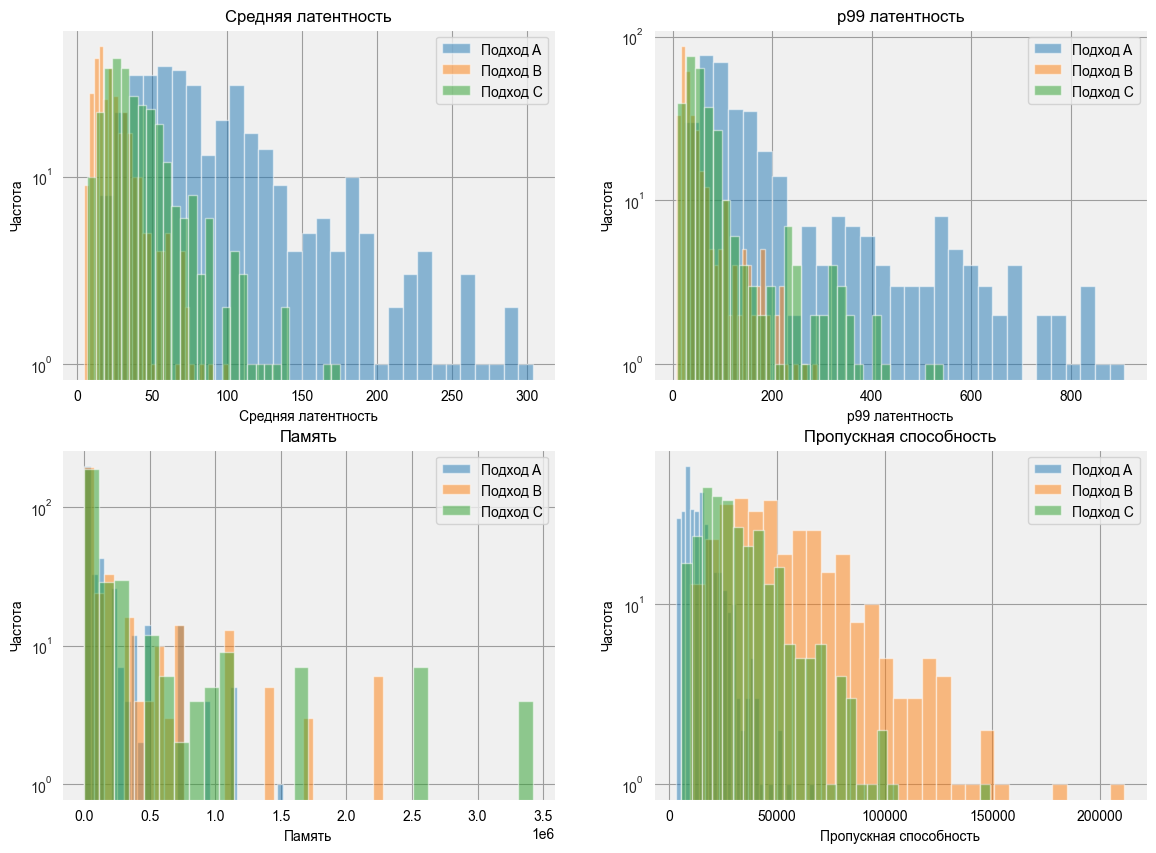

In [8]:
metrics = ['avg_latency', 'p99_latency', 'memory', 'throughput']
titles = ['Средняя латентность', 'p99 латентность', 'Память', 'Пропускная способность']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric, title in zip(axes.flat, metrics, titles):
    for approach in ['A','B','C']:
        subset = df[df['algorithmm']==approach][metric]
        ax.hist(subset, bins=30, alpha=0.5, label=f'Подход {approach}')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Частота')
    ax.legend()
    ax.set_yscale('log')

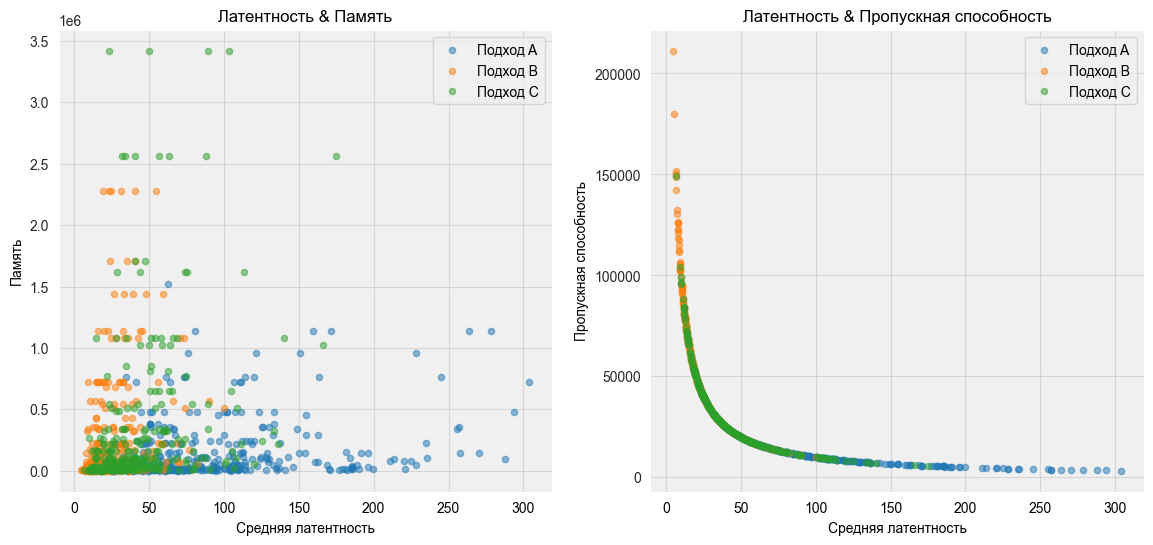

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for approach in ['A','B','C']:
    sub = df[df['algorithmm']==approach]
    axes[0].scatter(sub['avg_latency'], sub['memory'], alpha=0.5, s=20, label=f'Подход {approach}')
axes[0].set_xlabel('Средняя латентность')
axes[0].set_ylabel('Память')
axes[0].set_title('Латентность & Память')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for approach in ['A','B','C']:
    sub = df[df['algorithmm']==approach]
    axes[1].scatter(sub['avg_latency'], sub['throughput'], alpha=0.5, s=20, label=f'Подход {approach}')
axes[1].set_xlabel('Средняя латентность')
axes[1].set_ylabel('Пропускная способность')
axes[1].set_title('Латентность & Пропускная способность')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

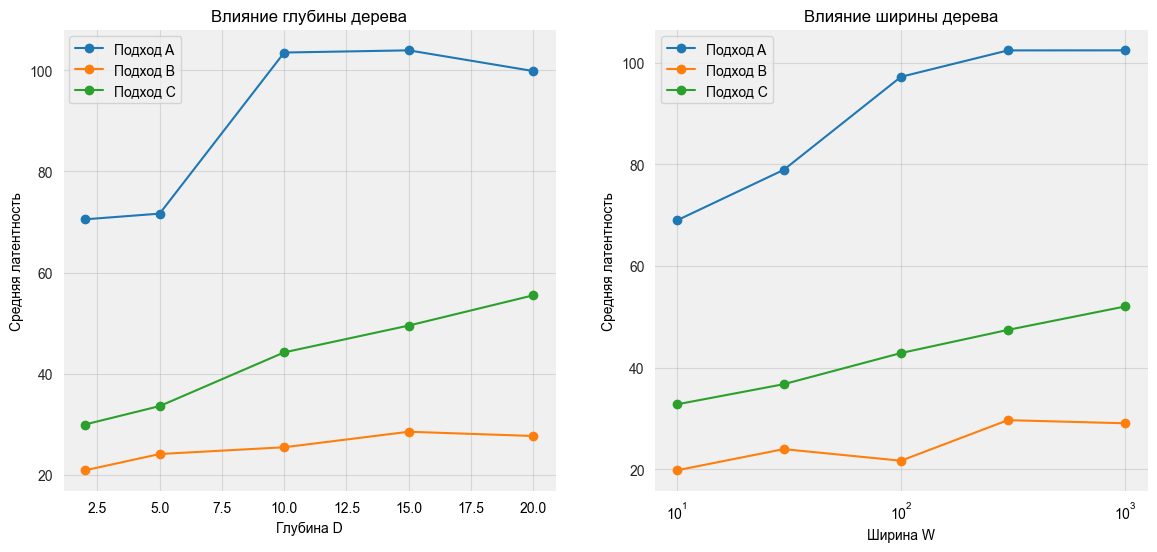

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for approach in ['A','B','C']:
    grouped = df[df['algorithmm']==approach].groupby('D')['avg_latency'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[0].set_xlabel('Глубина D')
axes[0].set_ylabel('Средняя латентность')
axes[0].set_title('Влияние глубины дерева')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for approach in ['A','B','C']:
    grouped = df[df['algorithmm']==approach].groupby('W')['avg_latency'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='o', label=f'Подход {approach}')
axes[1].set_xlabel('Ширина W')
axes[1].set_ylabel('Средняя латентность')
axes[1].set_title('Влияние ширины дерева')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

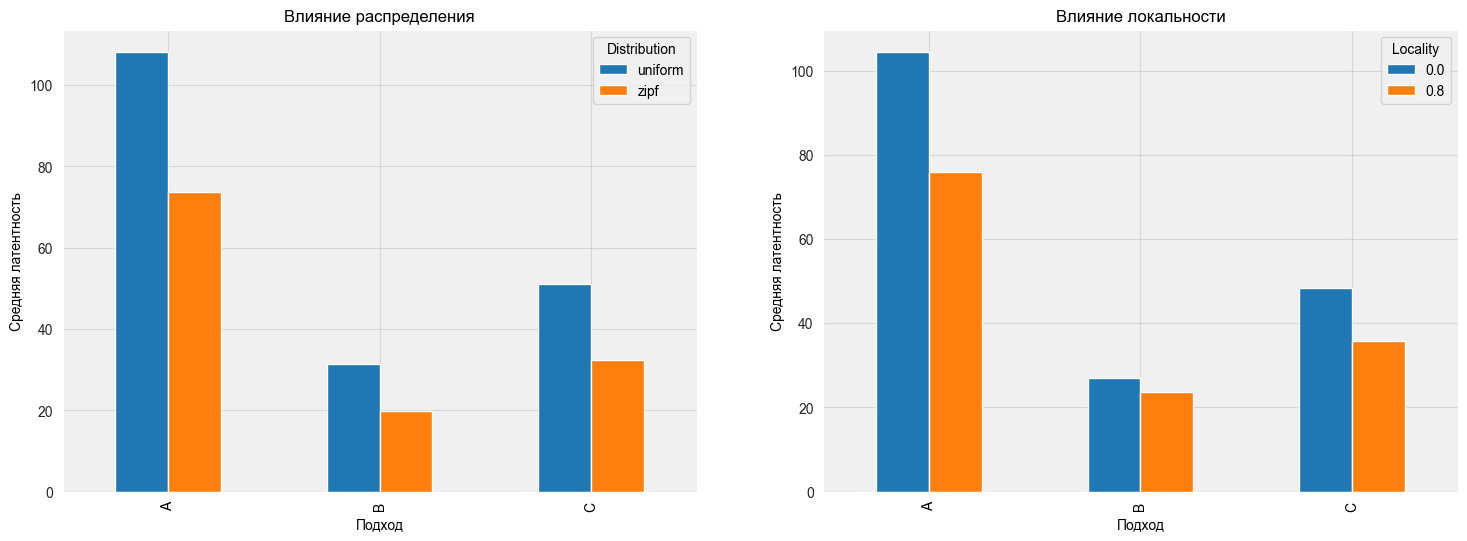

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

zipf_effect = df.groupby(['algorithmm','distribution'])['avg_latency'].mean().unstack()
zipf_effect.plot(kind='bar', ax=axes[0])
axes[0].set_title('Влияние распределения')
axes[0].set_xlabel('Подход')
axes[0].set_ylabel('Средняя латентность')
axes[0].legend(title='Distribution')
axes[0].grid(True, alpha=0.3)

loc_effect = df.groupby(['algorithmm','locality'])['avg_latency'].mean().unstack()
loc_effect.plot(kind='bar', ax=axes[1])
axes[1].set_title('Влияние локальности')
axes[1].set_xlabel('Подход')
axes[1].set_ylabel('Средняя латентность')
axes[1].legend(title='Locality')
axes[1].grid(True, alpha=0.3)

In [12]:
zipf_effect

distribution,uniform,zipf
algorithmm,,
A,108.265479,73.784054
B,31.373100,19.898080
C,51.106374,32.406407


Text(0.5, 1.0, 'Корреляционная матрица')

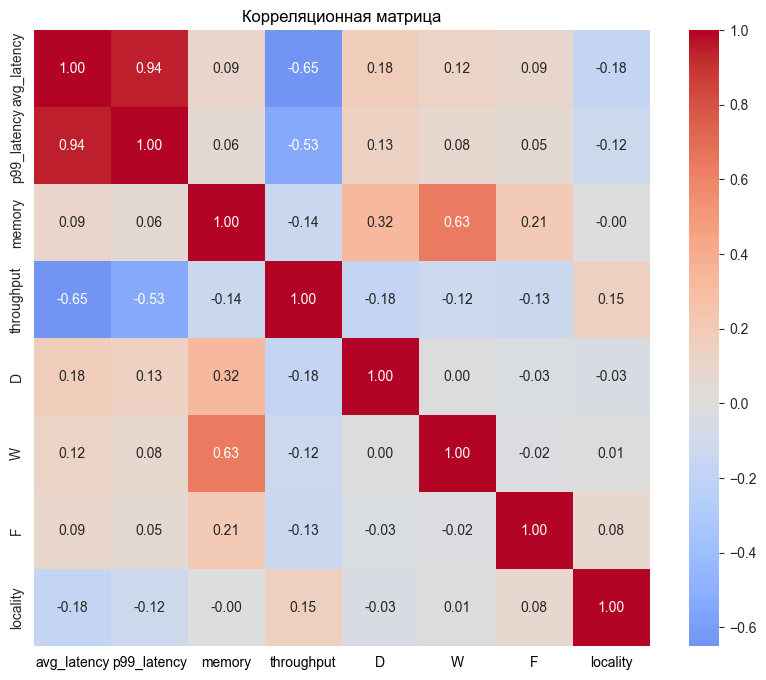

In [13]:
metric_cols = ['avg_latency','p99_latency','memory','throughput','D','W','F','locality']
corr = df[metric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Корреляционная матрица')

Коэффициент корреляции Пирсона между avg_latency и p99_latency: 0.945


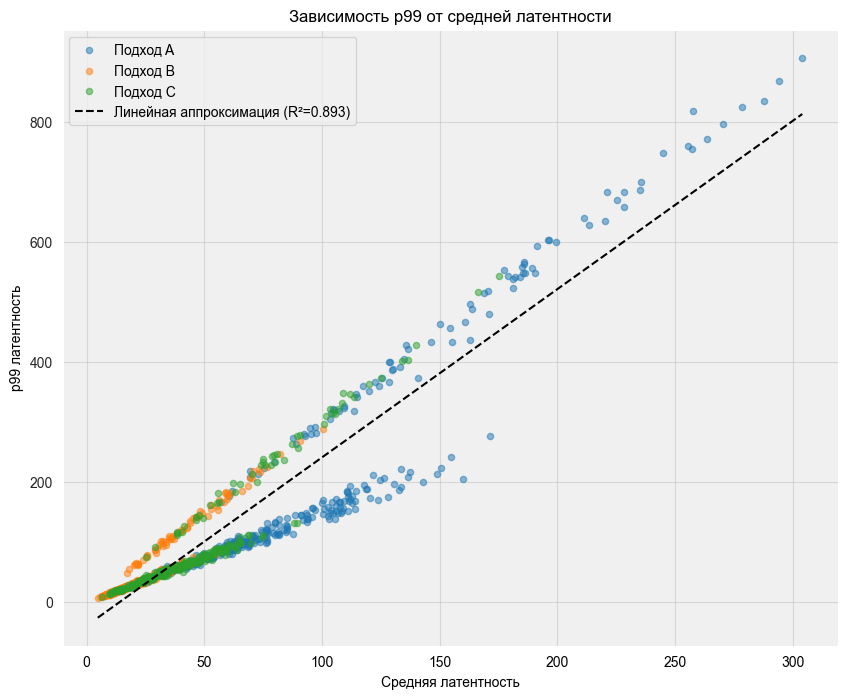

In [14]:
plt.figure(figsize=(10, 8))
for approach in ['A','B','C']:
    sub = df[df['algorithmm']==approach]
    plt.scatter(sub['avg_latency'], sub['p99_latency'], alpha=0.5, s=20, label=f'Подход {approach}')

coef = np.polyfit(df['avg_latency'], df['p99_latency'], 1)
p = np.poly1d(coef)
x_line = np.linspace(df['avg_latency'].min(), df['avg_latency'].max(), 100)
r2_lin = np.corrcoef(df['avg_latency'], df['p99_latency'])[0,1]**2
plt.plot(x_line, p(x_line), 'k--', label=f'Линейная аппроксимация (R²={r2_lin:.3f})')

plt.xlabel('Средняя латентность')
plt.ylabel('p99 латентность')
plt.title('Зависимость p99 от средней латентности')
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Коэффициент корреляции Пирсона между avg_latency и p99_latency: {pearsonr(df['avg_latency'], df['p99_latency'])[0]:.3f}")

In [15]:
def calculate_vif(X_df):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X_df.columns
    vif_data["VIF"] = [variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])]
    return vif_data.sort_values(by="VIF", ascending=False)

# Система A

In [16]:
df_ml = df[df["algorithmm"]== "A"].copy()

df_ml['logD'] = np.log(df_ml['D'])
df_ml['logW'] = np.log(df_ml['W'])
df_ml['logD_logW'] = df_ml['logD'] * df_ml['logW']
df_ml['D_W'] = df_ml['D'] * df_ml['W']

df_ml.loc[df_ml['distribution'] == 'uniform', 'zipf_s'] = 0

system_groups = df_ml['algorithmm'].copy()

df_ml = pd.get_dummies(df_ml, columns=['distribution'], drop_first=True)

feature_base = ['logD', 'logW', 'F', 'logD_logW', 'D_W', 'locality',
                'op_write', 'op_ls', 'op_mv', 'op_find', "op_read",
                'zipf_s', "D", "W"]

feature_cat = [c for c in df_ml.columns if c.startswith('dist_')]

features = feature_base + feature_cat

ordered_targets = ['memory', 'avg_latency', 'p99_latency', 'throughput']

X = df_ml[features]
Y_ordered = df_ml[ordered_targets]

print("Признаки:", features)
print("Размер X:", X.shape)

Признаки: ['logD', 'logW', 'F', 'logD_logW', 'D_W', 'locality', 'op_write', 'op_ls', 'op_mv', 'op_find', 'op_read', 'zipf_s', 'D', 'W']
Размер X: (365, 14)


In [17]:
display(calculate_vif(X[feature_base]))

,Feature,VIF
3,logD_logW,45.713030
0,logD,33.725696
1,logW,22.741386
10,op_read,22.469071
6,op_write,22.121043
9,op_find,19.934953
7,op_ls,17.314218
8,op_mv,15.836817
12,D,13.090981
4,D_W,12.965385


In [18]:
X_train, X_test, Y_train, Y_test, groups_train, _ = train_test_split(
    X, Y_ordered, system_groups, test_size=0.2, random_state=42
)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Y_train_scaled = scaler_Y.fit_transform(Y_train)

In [19]:
base_estimator = Ridge(random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

orders_to_try = [
    [0, 1, 2, 3],  # (Memory -> Avg Latency -> p99 -> Throughput)
    [0, 3, 1, 2],  # (Memory -> Throughput -> Avg Latency -> p99)
    [1, 2, 3, 0]   # (Avg Latency -> p99 -> Throughput -> Memory)
]

param_grid = {'base_estimator__alpha': np.logspace(-3, 3, 10), 'order':orders_to_try} 

chain = RegressorChain(
    base_estimator=Ridge(random_state=42), 
    random_state=42
)

grid_search = GridSearchCV(
    estimator=chain, 
    param_grid=param_grid, 
    cv=kf, 
    scoring='r2', 
    n_jobs=-1
)

grid_search.fit(X_train_scaled, Y_train_scaled)
best_chain_model = grid_search.best_estimator_

print(grid_search.best_params_)

{'base_estimator__alpha': np.float64(10.0), 'order': [0, 1, 2, 3]}


In [20]:
Y_pred_scaled = best_chain_model.predict(X_test_scaled)
Y_pred_original = scaler_Y.inverse_transform(Y_pred_scaled)

y_preds = pd.DataFrame(Y_pred_original, columns=ordered_targets, index=Y_test.index)

metrics_list = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds[target]
    
    r2 = r2_score(y_true, y_pr)
    mae = mean_absolute_error(y_true, y_pr)
    rmse = np.sqrt(mean_squared_error(y_true, y_pr))
    mape = mean_absolute_percentage_error(y_true, y_pr)
    max_ape = np.max(np.abs(y_true - y_pr) / np.clip(np.abs(y_true), 1e-8, None))
    
    metrics_list.append({
        'Target': target, 
        'R²': round(r2, 4), 
        'MAE': round(mae, 2), 
        'RMSE': round(rmse, 2),
        'MAPE': f"{mape*100:.2f}%", 
        'Max Error %': f"{max_ape*100:.2f}%"
    })

display(pd.DataFrame(metrics_list))

,Target,R²,MAE,RMSE,MAPE,Max Error %
0,memory,0.8047,62159.07,81600.51,1342.12%,20845.76%
1,avg_latency,0.7896,20.78,26.93,33.68%,261.34%
2,p99_latency,0.8604,52.92,74.13,50.17%,495.85%
3,throughput,0.6099,4418.62,7028.26,24.36%,54.65%


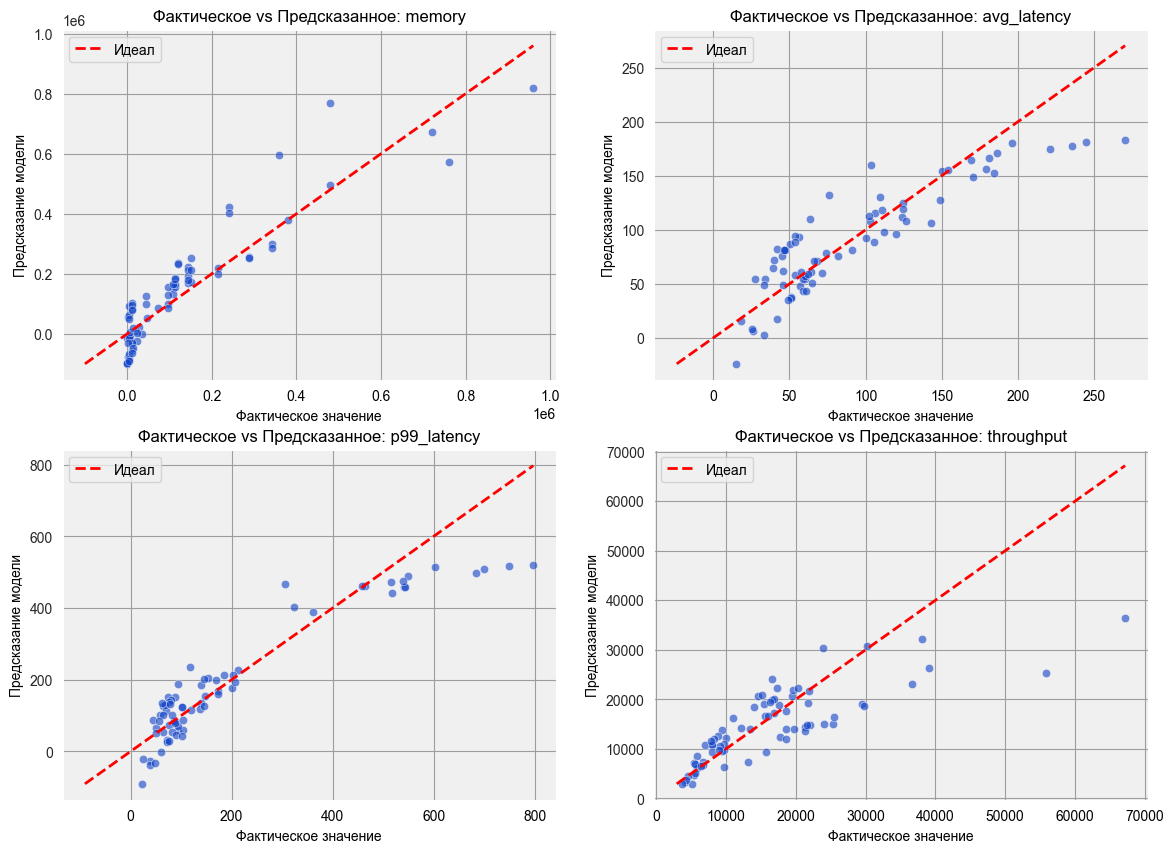

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds[target].min())
    max_val = max(Y_test[target].max(), y_preds[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')
    
    axes[i].set_title(f"Фактическое vs Предсказанное: {target}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание модели")
    axes[i].legend()

Text(0.5, 1.0, 'Корреляция ошибок предсказания (Остатки)')

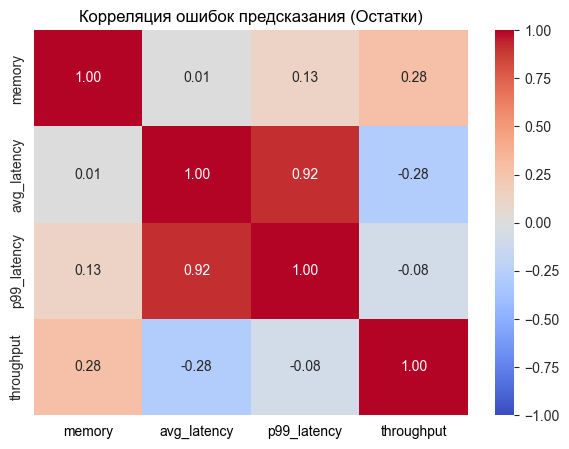

In [22]:
residuals = Y_test - y_preds

plt.figure(figsize=(7, 5))
sns.heatmap(residuals.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания (Остатки)")

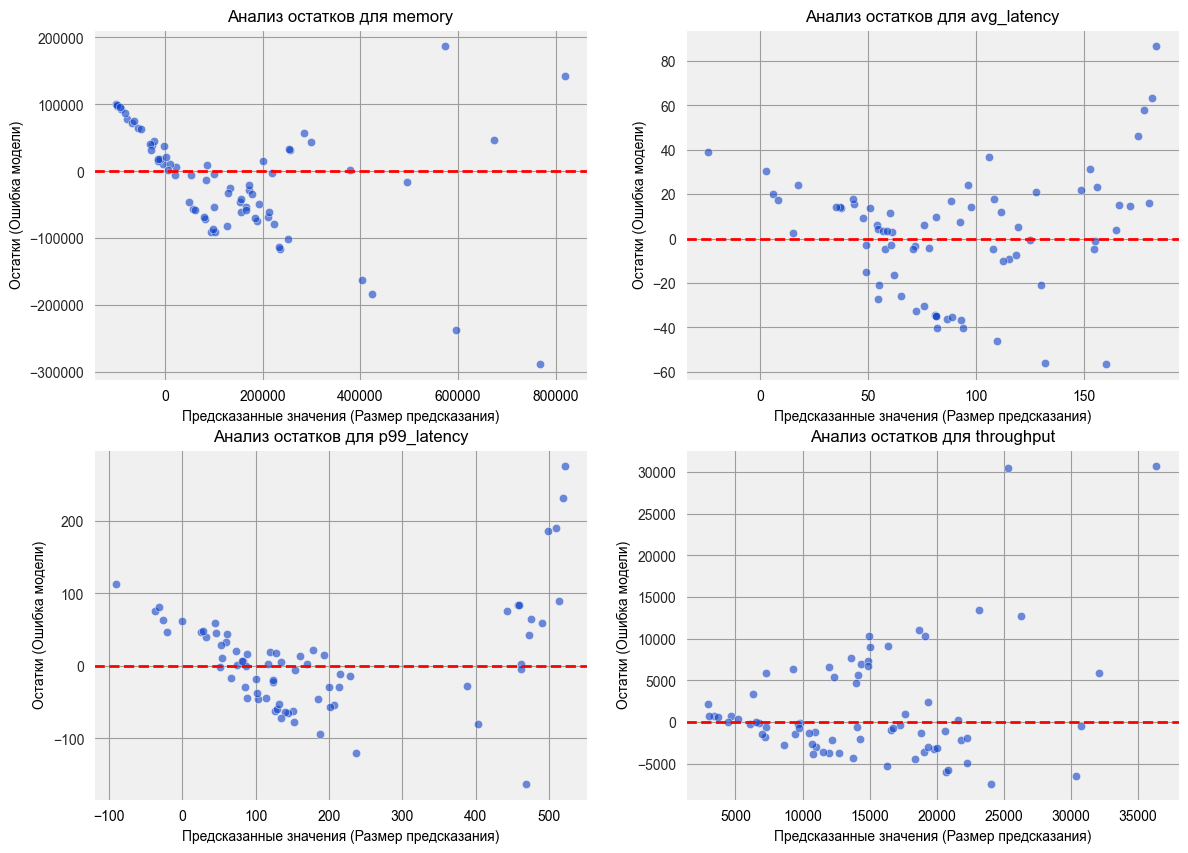

In [23]:
residuals = Y_test - y_preds

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=y_preds[target], y=residuals[target], ax=axes[i], alpha=0.6, color='#0F42C6')
    axes[i].axhline(y=0, color='r', linestyle='--', lw=2)
    
    axes[i].set_title(f"Анализ остатков для {target}")
    axes[i].set_xlabel("Предсказанные значения (Размер предсказания)")
    axes[i].set_ylabel("Остатки (Ошибка модели)")

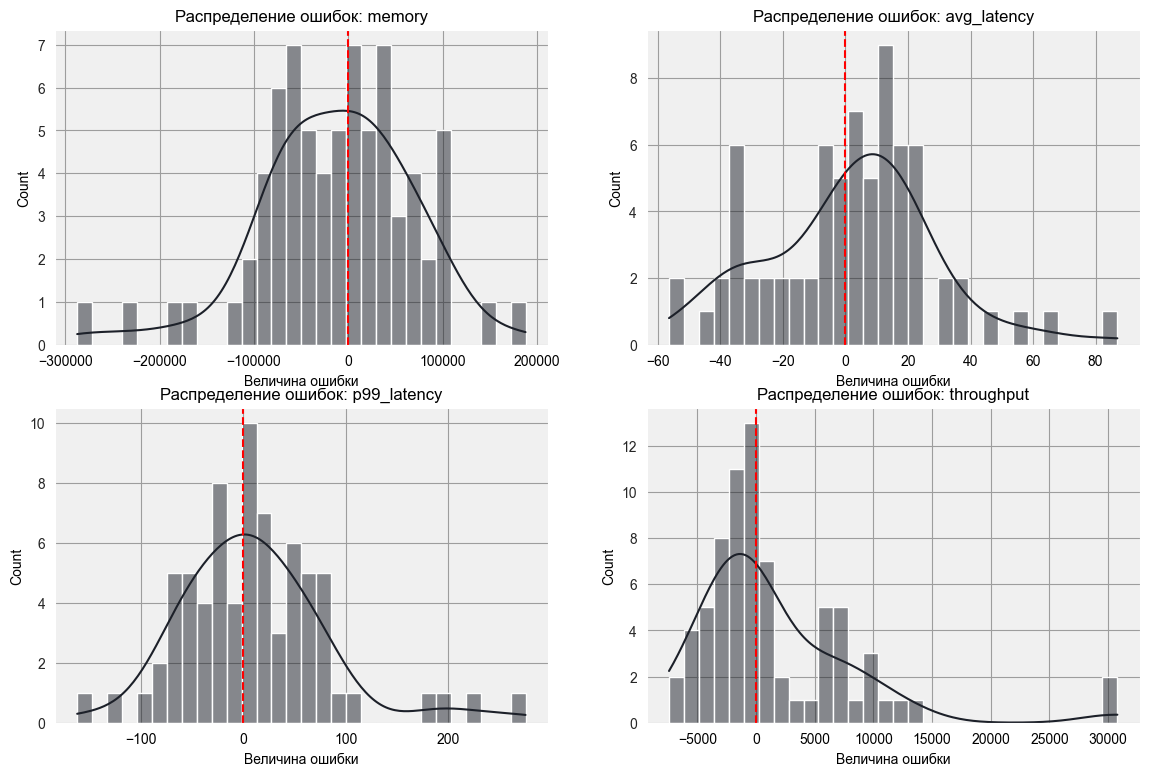

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(residuals[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")

# RANDOM FOREST

In [25]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import RegressorChain, MultiOutputRegressor

# система A

In [26]:
param_grid = {
    'estimator__n_estimators': [100, 200, 300],
    'estimator__max_depth': [None, 10, 20],
    'estimator__max_features': ['sqrt', 0.33, 'log2'],
    'estimator__min_samples_leaf': [1, 2, 5],
}

multi_rf = MultiOutputRegressor(
    RandomForestRegressor(random_state=42, oob_score=False)
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    multi_rf,
    param_grid,
    n_iter=20,
    cv=kf,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train_scaled, Y_train_scaled)
print("Лучшие параметры:", search.best_params_)
print("Лучший R² (CV):", round(search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Лучшие параметры: {'estimator__n_estimators': 200, 'estimator__min_samples_leaf': 5, 'estimator__max_features': 0.33, 'estimator__max_depth': 20}
Лучший R² (CV): 0.7409


In [27]:
best_params = {k.replace('estimator__', ''): v for k, v in search.best_params_.items()}
best_params['random_state'] = 42
best_params['oob_score'] = True

print("Параметры для цепочки:", best_params)

base_rf = RandomForestRegressor(**best_params)
chain_rf = RegressorChain(base_rf, order=[3, 0, 1, 2])
chain_rf.fit(X_train_scaled, Y_train_scaled)

print(f"\nOOB R² первого звена цепочки (memory): {chain_rf.estimators_[0].oob_score_:.4f}")

Параметры для цепочки: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.33, 'max_depth': 20, 'random_state': 42, 'oob_score': True}

OOB R² первого звена цепочки (memory): 0.6127


In [28]:
Y_pred_rf_scaled = chain_rf.predict(X_test_scaled)
Y_pred_rf = scaler_Y.inverse_transform(Y_pred_rf_scaled)

y_preds_rf = pd.DataFrame(Y_pred_rf, columns=ordered_targets, index=Y_test.index)

metrics_rf = []
for target in ordered_targets:
    y_true = Y_test[target]
    y_pr = y_preds_rf[target]
    metrics_rf.append({
        'Target': target,
        'R²': round(r2_score(y_true, y_pr), 4),
        'MAE': round(mean_absolute_error(y_true, y_pr), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pr)), 2),
        'MAPE': f"{mean_absolute_percentage_error(y_true, y_pr)*100:.2f}%",
    })

display(pd.DataFrame(metrics_rf))

,Target,R²,MAE,RMSE,MAPE
0,memory,0.8605,36706.30,68948.64,53.58%
1,avg_latency,0.7635,21.72,28.55,28.84%
2,p99_latency,0.8679,46.45,72.11,30.03%
3,throughput,0.5416,4707.97,7619.61,28.26%


Text(0.5, 1.02, 'Random Forest: Фактическое vs Предсказанное')

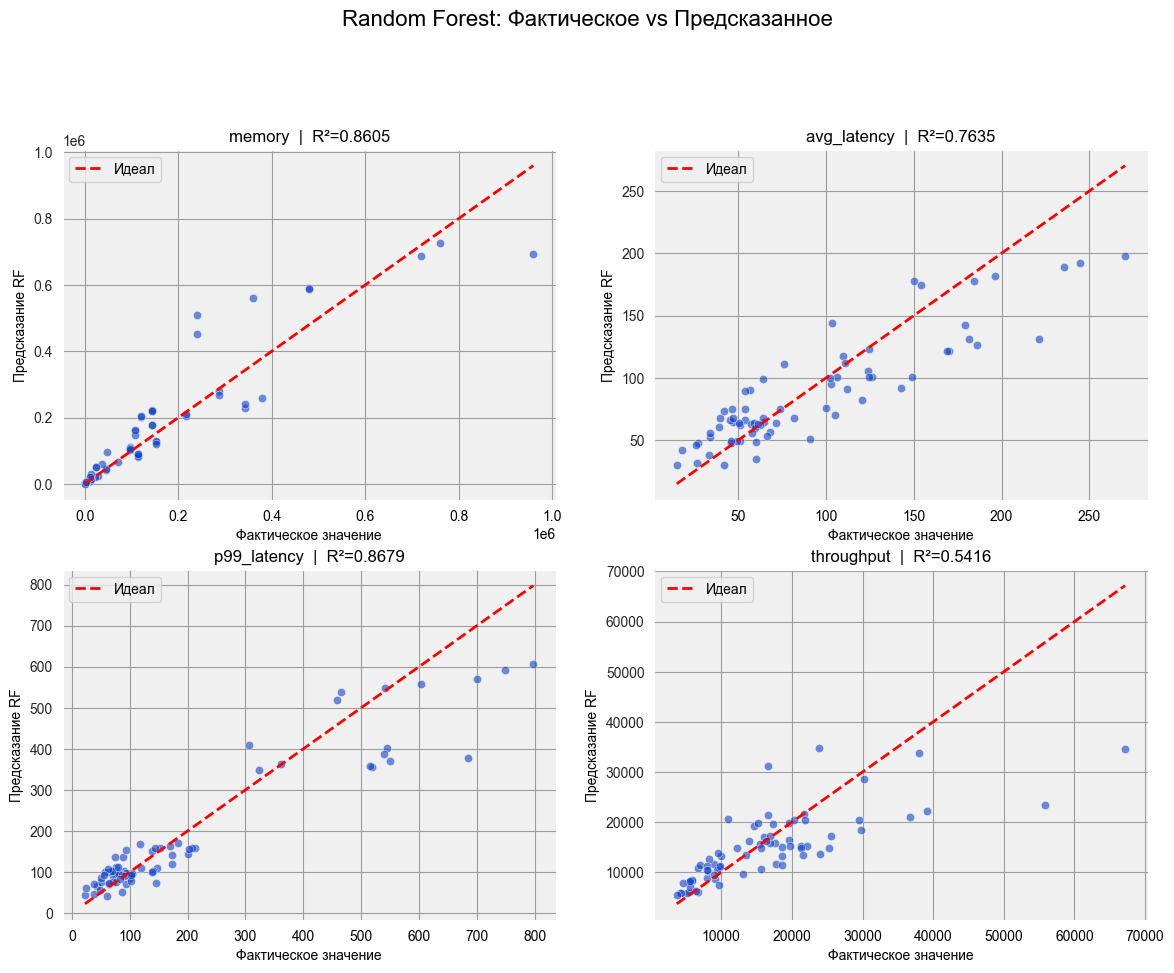

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=Y_test[target], y=y_preds_rf[target], ax=axes[i], alpha=0.6, color='#0F42C6')

    min_val = min(Y_test[target].min(), y_preds_rf[target].min())
    max_val = max(Y_test[target].max(), y_preds_rf[target].max())
    axes[i].plot([min_val, max_val], [min_val, max_val], '--r', lw=2, label='Идеал')

    r2 = r2_score(Y_test[target], y_preds_rf[target])
    axes[i].set_title(f"{target}  |  R²={r2:.4f}")
    axes[i].set_xlabel("Фактическое значение")
    axes[i].set_ylabel("Предсказание RF")
    axes[i].legend()

plt.suptitle("Random Forest: Фактическое vs Предсказанное", fontsize=16, y=1.02)

Text(0.5, 1.02, 'Random Forest: Анализ остатков')

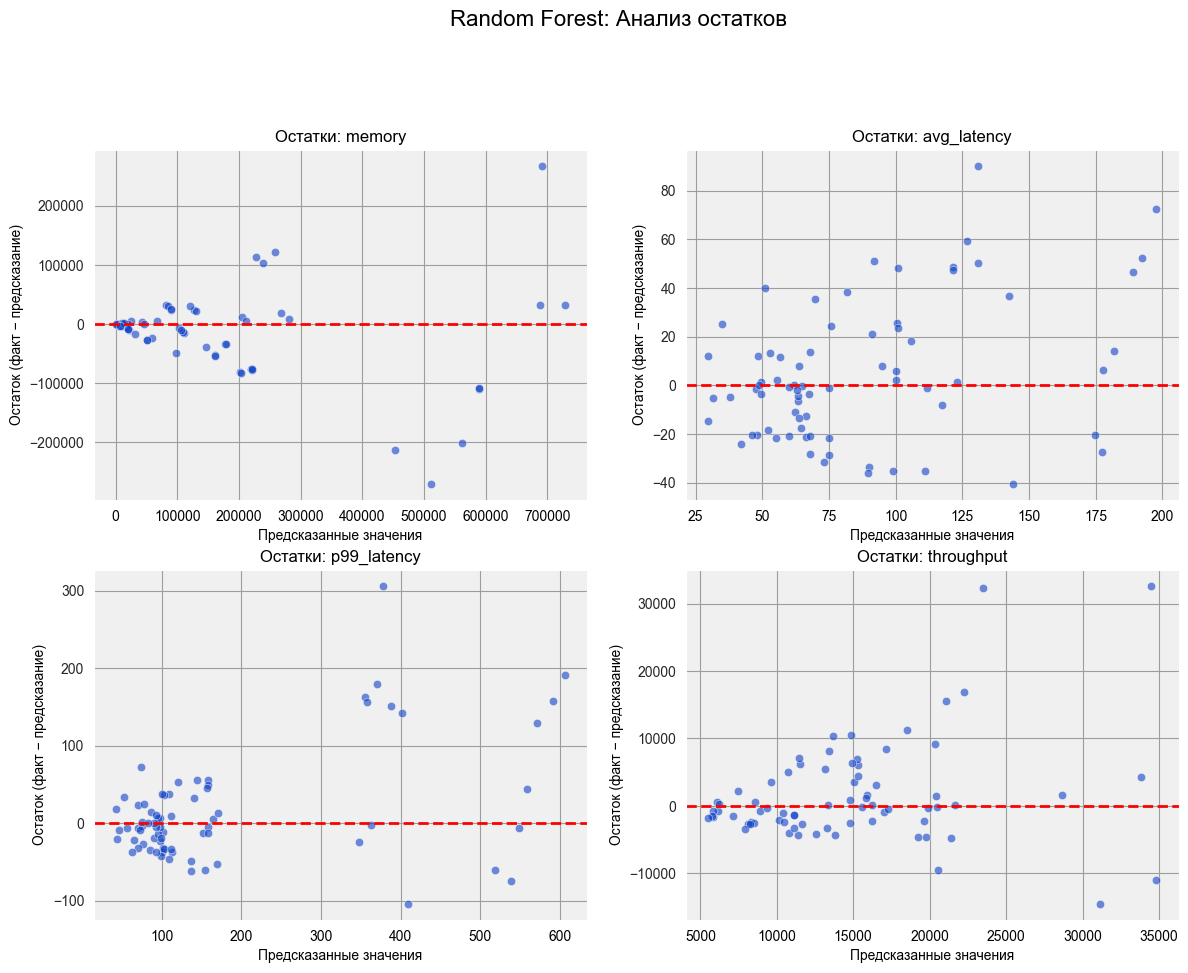

In [30]:
residuals_rf = Y_test.values - Y_pred_rf
resid_df = pd.DataFrame(residuals_rf, columns=ordered_targets, index=Y_test.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.scatterplot(x=y_preds_rf[target], y=resid_df[target], ax=axes[i], alpha=0.6, color='#0F42C6')
    axes[i].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[i].set_title(f"Остатки: {target}")
    axes[i].set_xlabel("Предсказанные значения")
    axes[i].set_ylabel("Остаток (факт − предсказание)")

plt.suptitle("Random Forest: Анализ остатков", fontsize=16, y=1.02)

Text(0.5, 1.02, 'Random Forest: Распределение остатков')

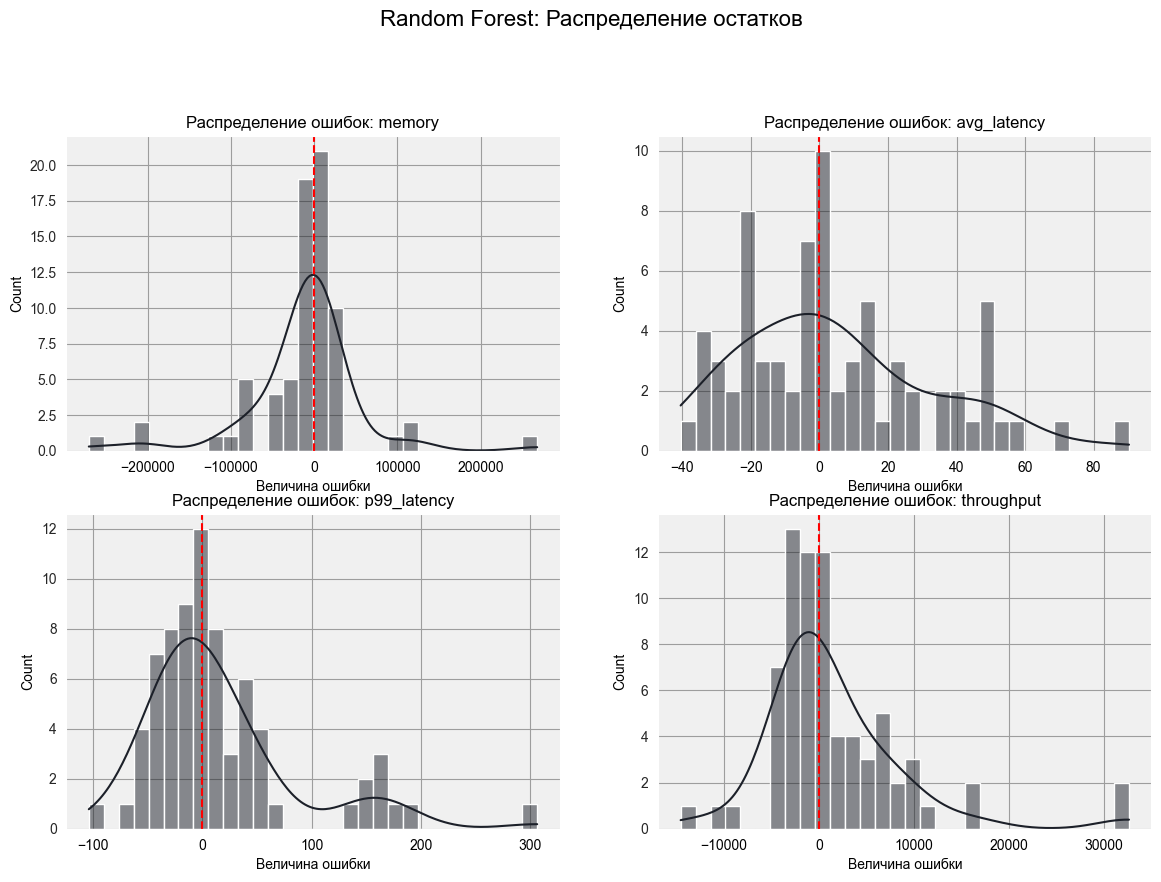

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for i, target in enumerate(ordered_targets):
    sns.histplot(resid_df[target], kde=True, ax=axes[i], color='#1C2029', bins=30)
    axes[i].axvline(x=0, color='r', linestyle='--')
    axes[i].set_title(f"Распределение ошибок: {target}")
    axes[i].set_xlabel("Величина ошибки")

plt.suptitle("Random Forest: Распределение остатков", fontsize=16, y=1.02)

Text(0.5, 1.0, 'Корреляция ошибок предсказания RF (остатки)')

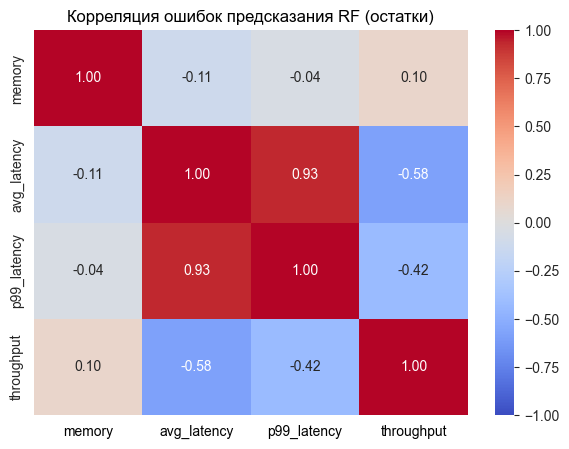

In [32]:
plt.figure(figsize=(7, 5))
sns.heatmap(resid_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Корреляция ошибок предсказания RF (остатки)")

Text(0.5, 1.02, 'Random Forest: Важность признаков по звеньям цепочки')

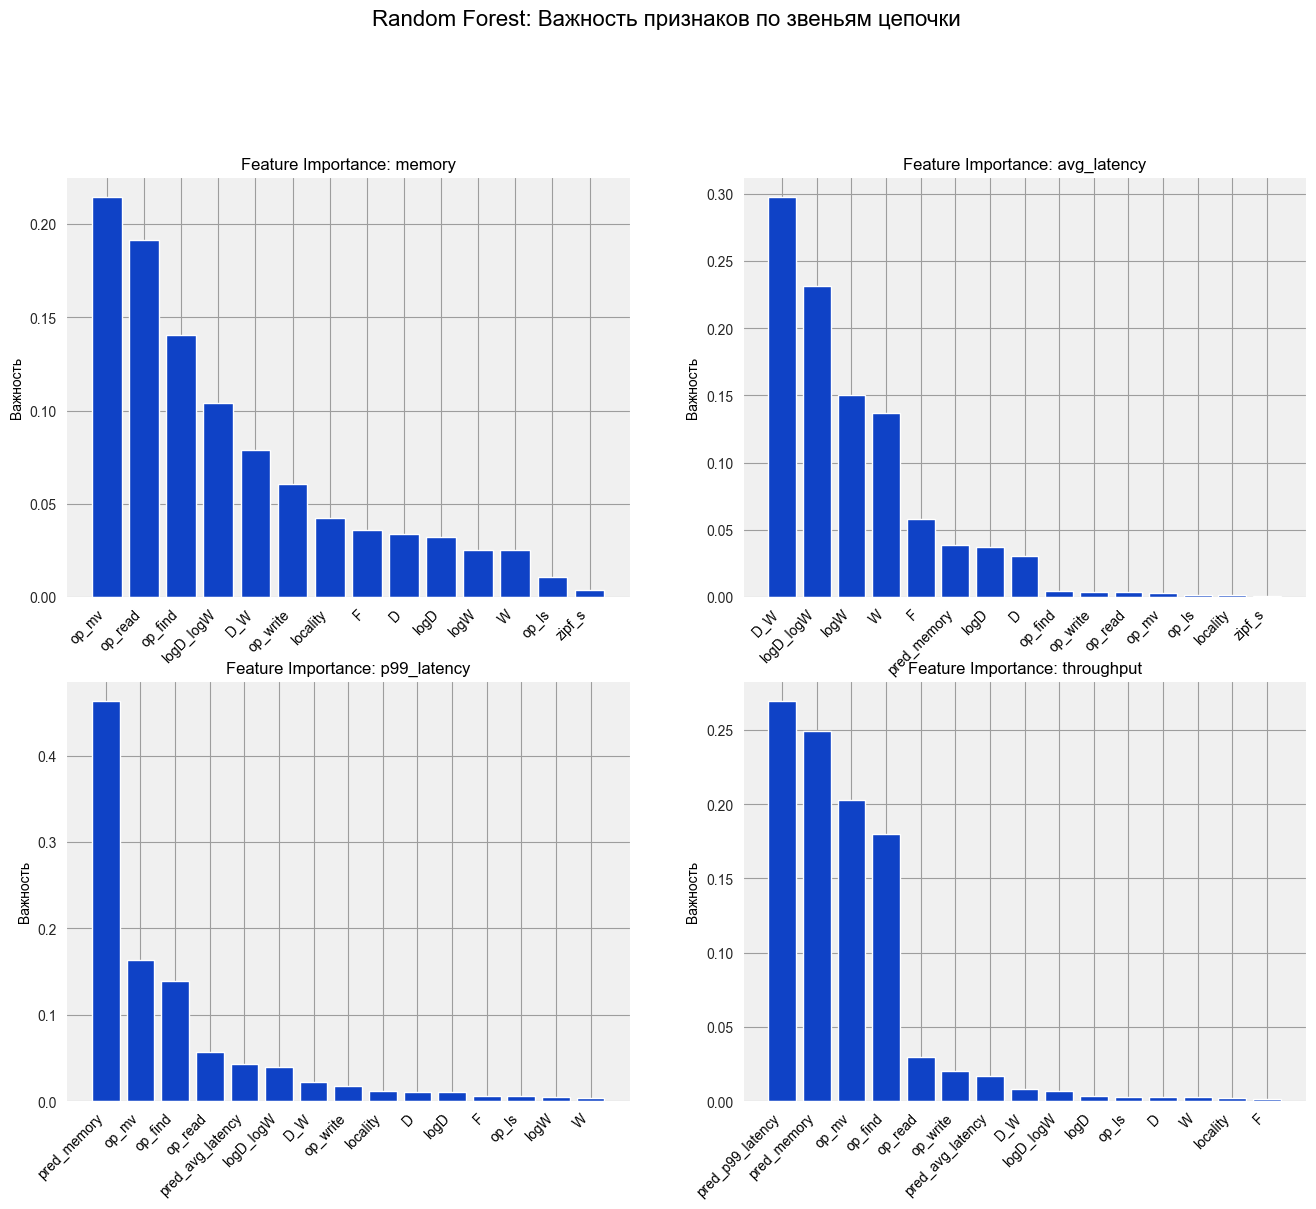

In [33]:
real_feature_names = list(X_train.columns)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, (estimator, target) in enumerate(zip(chain_rf.estimators_, ordered_targets)):
    n_original = len(real_feature_names)
    n_extra = estimator.n_features_in_ - n_original
    extra_names = [f"pred_{ordered_targets[j]}" for j in range(n_extra)]
    all_names = real_feature_names + extra_names

    importances = estimator.feature_importances_
    sorted_idx = np.argsort(importances)[::-1][:15]  # топ-15

    axes[i].bar(range(len(sorted_idx)), importances[sorted_idx], color='#0F42C6')
    axes[i].set_xticks(range(len(sorted_idx)))
    axes[i].set_xticklabels([all_names[j] for j in sorted_idx], rotation=45, ha='right', fontsize=10)
    axes[i].set_title(f"Feature Importance: {target}")
    axes[i].set_ylabel("Важность")

plt.suptitle("Random Forest: Важность признаков по звеньям цепочки", fontsize=16, y=1.02)

Text(0.5, 0.98, 'Partial Dependence: memory от logD и logW')

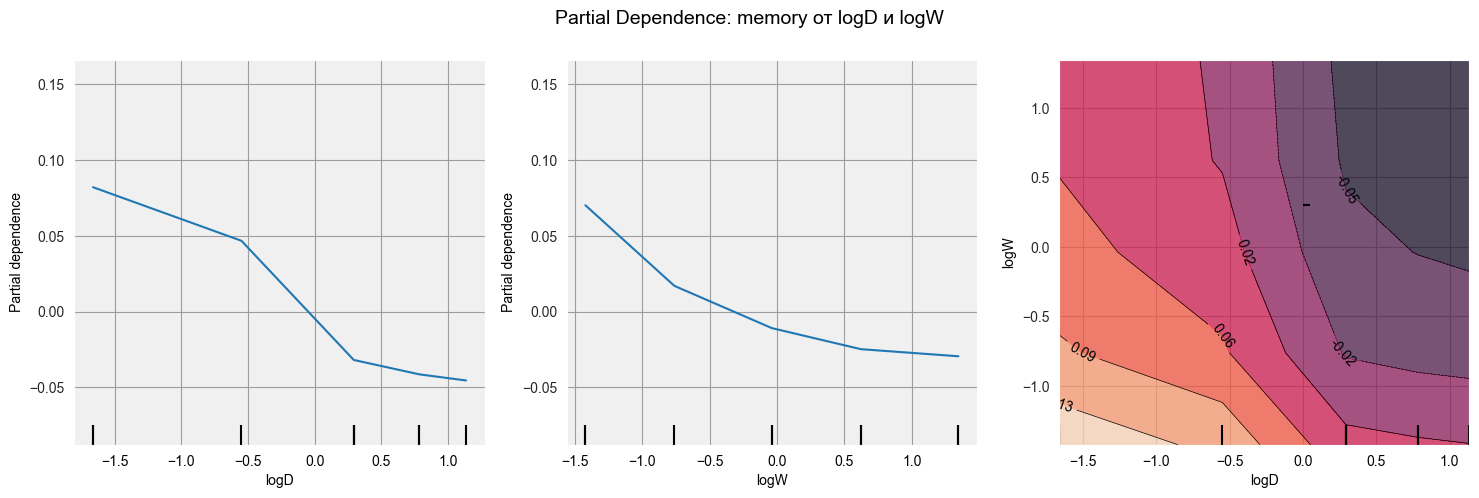

In [34]:
real_feature_names = list(X_train.columns)
logD_idx = real_feature_names.index('logD')
logW_idx = real_feature_names.index('logW')
F_idx = real_feature_names.index('F')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

PartialDependenceDisplay.from_estimator(
    chain_rf.estimators_[0],
    X_train_scaled,
    features=[logD_idx, logW_idx, (logD_idx, logW_idx)],
    feature_names=real_feature_names,
    ax=axes
)

plt.suptitle("Partial Dependence: memory от logD и logW", fontsize=14)